In [ ]:
import zipfile
import os

zip_path = "ANN_Project.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [ ]:
import os

print(os.listdir("/content/ANN_Project"))

['Clean', 'moderate', 'Dirty']


In [ ]:
import os

dataset_path = "/content/ANN_Project"

for folder in ["Clean", "moderate", "Dirty"]:
    path = os.path.join(dataset_path, folder)
    images = os.listdir(path)
    print(folder, "=", len(images), "images")

Clean = 14 images
moderate = 14 images
Dirty = 15 images


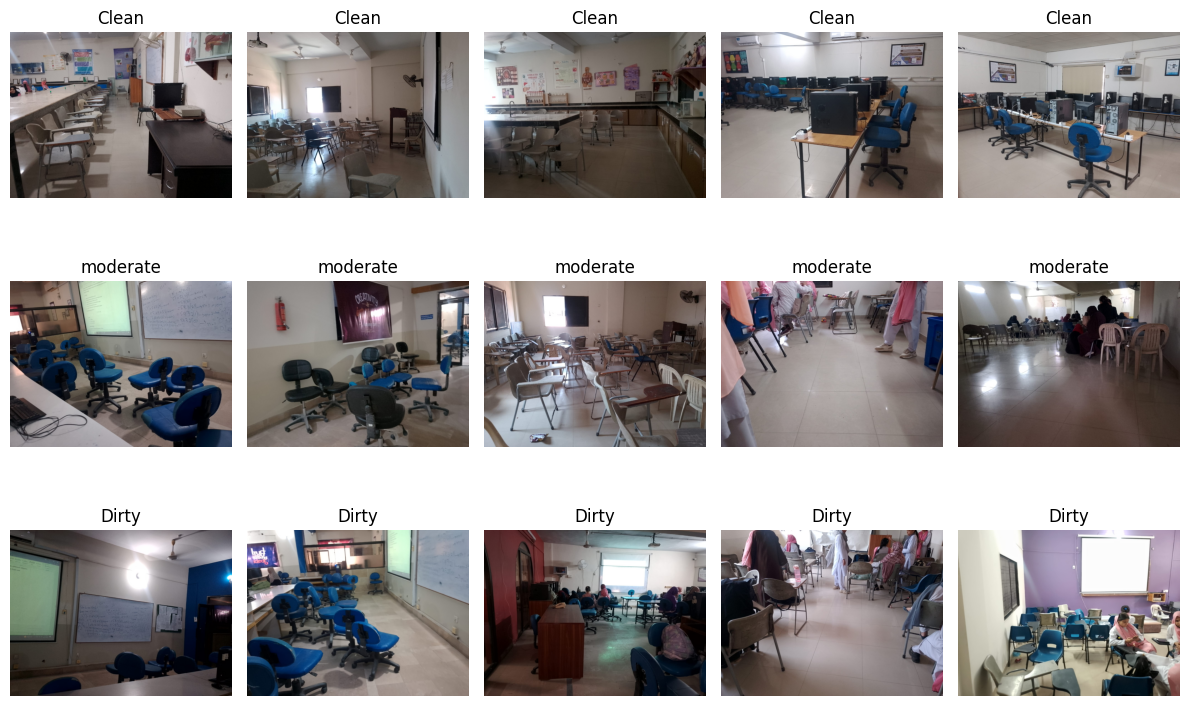

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

dataset_path = "/content/ANN_Project"

classes = ["Clean", "moderate", "Dirty"]

plt.figure(figsize=(12, 8))

plot_number = 1

for class_name in classes:
    folder_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(folder_path)[:5]:
        image_path = os.path.join(folder_path, file_name)

        image = Image.open(image_path)

        plt.subplot(3, 5, plot_number)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

        plot_number += 1

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 64

print("Image size:", IMG_SIZE, "x", IMG_SIZE)

Image size: 64 x 64


In [ ]:
import numpy as np
import os
from PIL import Image

dataset_path = "/content/ANN_Project"

classes = ["Clean", "moderate", "Dirty"]

X = []
y = []

for label, class_name in enumerate(classes):

    folder_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(folder_path):

        file_path = os.path.join(folder_path, file_name)

        try:
            image = Image.open(file_path).convert("RGB")
            image = image.resize((IMG_SIZE, IMG_SIZE))

            X.append(np.array(image))
            y.append(label)

        except:
            print("Could not read:", file_name)

X = np.array(X)
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (43, 64, 64, 3)
Labels: (43,)


In [ ]:
X = X / 255.0

print("Minimum:", X.min())
print("Maximum:", X.max())

Minimum: 0.0
Maximum: 1.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 34
Testing images: 9


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(3, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.3824 - loss: 3.7264 - val_accuracy: 0.4444 - val_loss: 1.9319
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4706 - loss: 3.8982 - val_accuracy: 0.3333 - val_loss: 4.3325
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3529 - loss: 3.2796 - val_accuracy: 0.3333 - val_loss: 1.6838
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4412 - loss: 1.9250 - val_accuracy: 0.3333 - val_loss: 1.7002
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5588 - loss: 1.6370 - val_accuracy: 0.2222 - val_loss: 1.7340
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4118 - loss: 2.1274 - val_accuracy: 0.3333 - val_loss: 1.9322
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4118 - loss: 1.6847 - val_accuracy: 0.2222 - val_loss: 1.5285
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5882 - loss: 1.1491 - val_accuracy: 0.1111 - val_loss: 1.8337

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3333 - loss: 1.6896
Test Accuracy: 0.3333333432674408
Test Loss: 1.689557671546936


In [ ]:
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Accuracy: 33.33 %


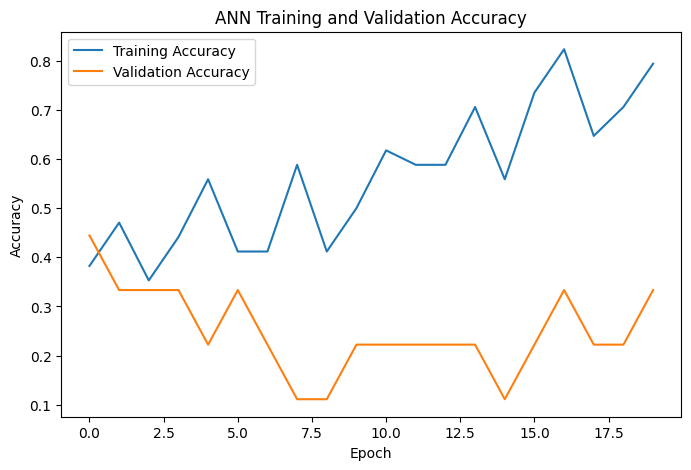

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

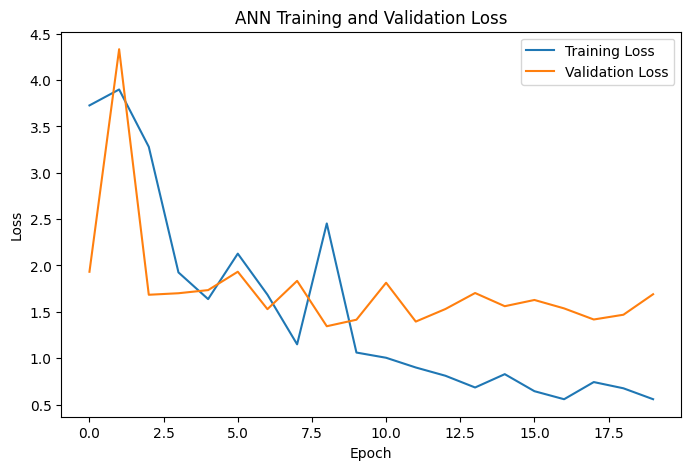

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import numpy as np

y_probability = model.predict(X_test)

y_pred = np.argmax(y_probability, axis=1)

print("Actual labels:   ", y_test)
print("Predicted labels:", y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
Actual labels:    [0 0 2 1 1 2 1 2 0]
Predicted labels: [0 1 1 1 2 1 1 1 1]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 2 0]
 [0 2 1]
 [0 3 0]]


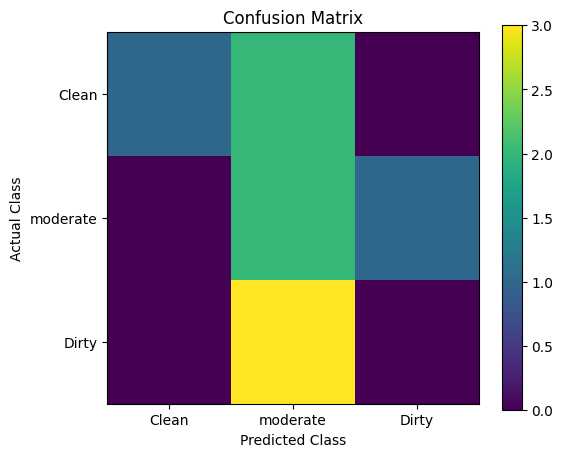

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1, 2], classes)
plt.yticks([0, 1, 2], classes)

plt.colorbar()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=classes
)

print(report)

              precision    recall  f1-score   support

       Clean       1.00      0.33      0.50         3
    moderate       0.29      0.67      0.40         3
       Dirty       0.00      0.00      0.00         3

    accuracy                           0.33         9
   macro avg       0.43      0.33      0.30         9
weighted avg       0.43      0.33      0.30         9



In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "1.jfif"

image = Image.open(image_path).convert("RGB")
image = image.resize((64, 64))

image_array = np.array(image) / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

NameError: name 'model' is not defined

In [ ]:
import os
import numpy as np
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

dataset_path = "/content/ANN_Project"

classes = ["Clean", "moderate", "Dirty"]
IMG_SIZE = 64

X = []
y = []

for label, class_name in enumerate(classes):
    folder_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        try:
            image = Image.open(file_path).convert("RGB")
            image = image.resize((IMG_SIZE, IMG_SIZE))

            X.append(np.array(image))
            y.append(label)

        except:
            pass

X = np.array(X) / 255.0
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/ANN_Project/Clean'

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving New_test_pic.zip to New_test_pic.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("/content/New_test_pic.zip", "r") as zip_ref:
    print(zip_ref.namelist())

['New_test_pic/1.jfif']


In [ ]:
import zipfile

with zipfile.ZipFile("/content/New_test_pic.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Image extracted successfully!")

Image extracted successfully!


In [ ]:
import os

print(os.listdir("/content/New_test_pic"))

['1.jfif']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ANN_Project.zip to ANN_Project.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("/content/ANN_Project.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("/content/ANN_Project"))

['Clean', 'moderate', 'Dirty']


In [ ]:
import os
import numpy as np
from PIL import Image

dataset_path = "/content/ANN_Project"

classes = ["Clean", "moderate", "Dirty"]
IMG_SIZE = 64

X = []
y = []

for label, class_name in enumerate(classes):
    folder_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        try:
            image = Image.open(file_path).convert("RGB")
            image = image.resize((IMG_SIZE, IMG_SIZE))

            X.append(np.array(image))
            y.append(label)

        except:
            pass

X = np.array(X) / 255.0
y = np.array(y)

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (43, 64, 64, 3)
Labels: (43,)


In [ ]:
print(X.shape)
print(y.shape)

(43, 64, 64, 3)
(43,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 34
Testing images: 9


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(64, 64, 3)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.2941 - loss: 3.1660 - val_accuracy: 0.3333 - val_loss: 4.1638
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4412 - loss: 3.0280 - val_accuracy: 0.3333 - val_loss: 2.0114
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3235 - loss: 2.9347 - val_accuracy: 0.3333 - val_loss: 2.2580
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5882 - loss: 1.9045 - val_accuracy: 0.3333 - val_loss: 1.7696
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 1.7891 - val_accuracy: 0.3333 - val_loss: 1.9946
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4706 - loss: 2.0898 - val_accuracy: 0.2222 - val_loss: 2.2769
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6471 - loss: 1.3003 - val_accuracy: 0.3333 - val_loss: 3.6878
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5882 - loss: 1.6184 - val_accuracy: 0.3333 - val_loss: 2.7746


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.2222 - loss: 2.3071
Test Accuracy: 22.22 %


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


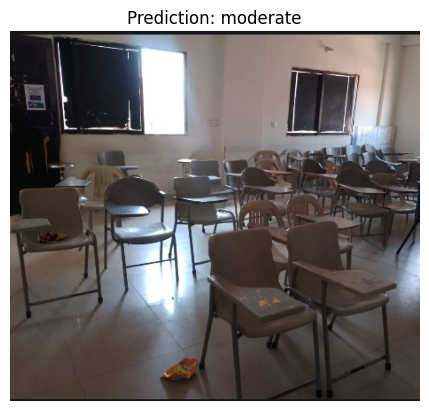

Predicted Class: moderate
Confidence: 87.16 %


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Test image
image_path = "/content/New_test_pic/1.jfif"

# Open image
image = Image.open(image_path).convert("RGB")

# Resize same as training
image_resized = image.resize((64, 64))

# Normalize
image_array = np.array(image_resized) / 255.0

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Prediction
prediction = model.predict(image_array)

# Get class
predicted_class = classes[np.argmax(prediction)]

# Confidence
confidence = np.max(prediction) * 100

# Show image
plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_img_2.zip to test_img_2.zip


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'ANN_Project', '1.jfif', 'ANN_Project.zip', 'test-new', 'New_test_pic.zip', '.ipynb_checkpoints', 'New_test_pic', 'test_img_2.zip', 'sample_data']


In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Find test_img_2 file
files = [f for f in os.listdir("/content") if f.startswith("test_img_2")]

print("Found:", files)

Found: ['test_img_2.zip']


In [ ]:
import zipfile
import os

with zipfile.ZipFile("/content/test_img_2.zip", "r") as zip_ref:
    zip_ref.extractall("/content/test_img_2")

print(os.listdir("/content/test_img_2"))

['test_img_2']


In [ ]:
import os

print(os.listdir("/content/test_img_2"))

['test_img_2']


In [ ]:
import os

for root, dirs, files in os.walk("/content/test_img_2"):
    print("Folder:", root)
    print("Files:", files)

Folder: /content/test_img_2
Files: []
Folder: /content/test_img_2/test_img_2
Files: ['test_img.jfif']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


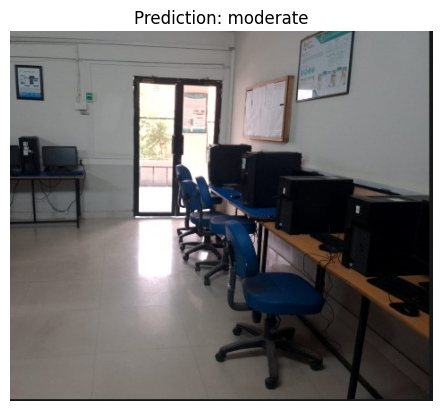

Predicted Class: moderate
Confidence: 81.11 %


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/test_img_2/test_img_2/test_img.jfif"

image = Image.open(image_path).convert("RGB")
image_resized = image.resize((64, 64))

image_array = np.array(image_resized) / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


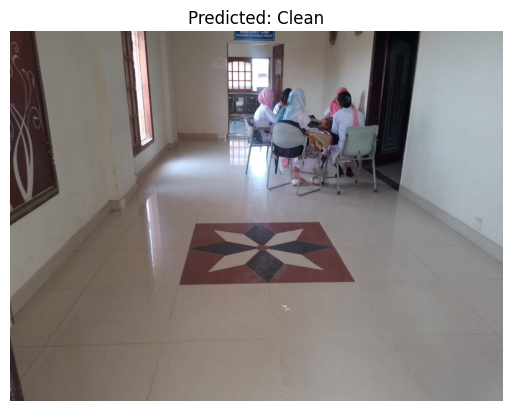

Selected Image: 7.jfif
Actual Folder: Clean
Predicted Class: Clean
Confidence: 50.98 %


In [ ]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Clean folder ka path
clean_folder = "/content/ANN_Project/Clean"

# Clean folder se images ki list
images = [
    os.path.join(clean_folder, file)
    for file in os.listdir(clean_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))
]

# Automatically 1 image select
image_path = random.choice(images)

# Image open karo
image = Image.open(image_path).convert("RGB")

# Model ke size ke according resize
image_resized = image.resize((64, 64))

# Normalize
image_array = np.array(image_resized) / 255.0

# Batch dimension add
image_array = np.expand_dims(image_array, axis=0)

# Prediction
prediction = model.predict(image_array)

# Class aur confidence
predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Image show
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}")
plt.show()

print("Selected Image:", os.path.basename(image_path))
print("Actual Folder: Clean")
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


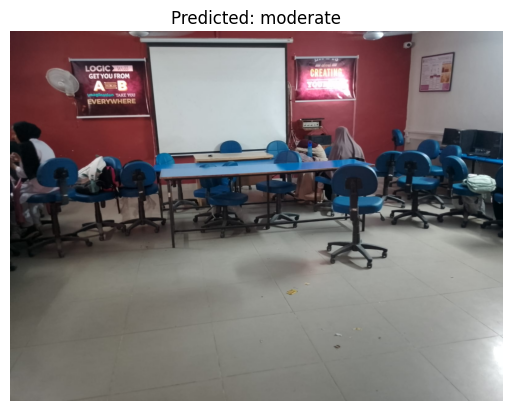

Selected Image: 11.jfif
Actual Folder: Dirty
Predicted Class: moderate
Confidence: 60.5 %


In [ ]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dirty folder ka path
dirty_folder = "/content/ANN_Project/Dirty"

# Dirty folder se images ki list
images = [
    os.path.join(dirty_folder, file)
    for file in os.listdir(dirty_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))
]

# Automatically 1 image select
image_path = random.choice(images)

# Image open karo
image = Image.open(image_path).convert("RGB")

# Resize
image_resized = image.resize((64, 64))

# Normalize
image_array = np.array(image_resized) / 255.0

# Batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Prediction
prediction = model.predict(image_array)

# Class and confidence
predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show image
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}")
plt.show()

print("Selected Image:", os.path.basename(image_path))
print("Actual Folder: Dirty")
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

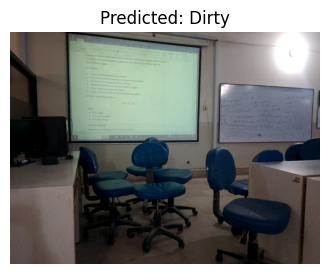

Selected Image: 3.jfif
Actual Folder: Dirty
Predicted Class: Dirty
Confidence: 93.44 %
--------------------------------


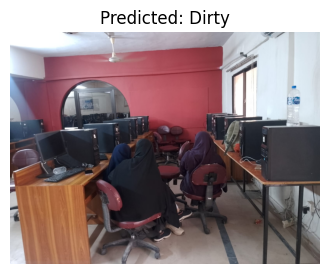

Selected Image: 7.jfif
Actual Folder: Dirty
Predicted Class: Dirty
Confidence: 76.81 %
--------------------------------


In [ ]:
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

dirty_folder = "/content/ANN_Project/Dirty"

# Dirty folder ki images
images = [
    os.path.join(dirty_folder, file)
    for file in os.listdir(dirty_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))
]

# 2 random images select
selected_images = random.sample(images, 2)

for image_path in selected_images:

    # Image open
    image = Image.open(image_path).convert("RGB")

    # Resize
    image_resized = image.resize((64, 64))

    # Normalize
    image_array = np.array(image_resized) / 255.0

    # Batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    prediction = model.predict(image_array, verbose=0)

    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Show image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class}")
    plt.show()

    print("Selected Image:", os.path.basename(image_path))
    print("Actual Folder: Dirty")
    print("Predicted Class:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")
    print("--------------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step


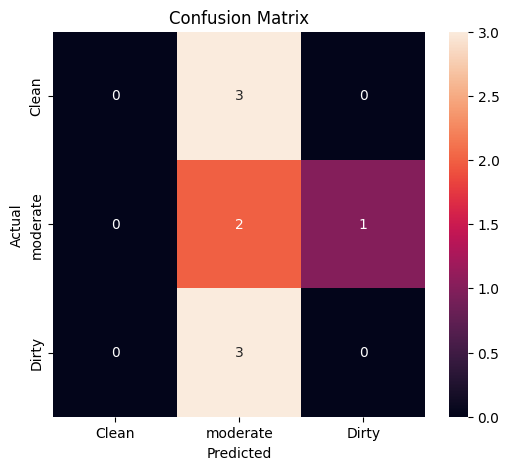

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_probability = model.predict(X_test)
y_pred = np.argmax(y_probability, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00         3
    moderate       0.25      0.67      0.36         3
       Dirty       0.00      0.00      0.00         3

    accuracy                           0.22         9
   macro avg       0.08      0.22      0.12         9
weighted avg       0.08      0.22      0.12         9



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Accuracy: 22.22 %


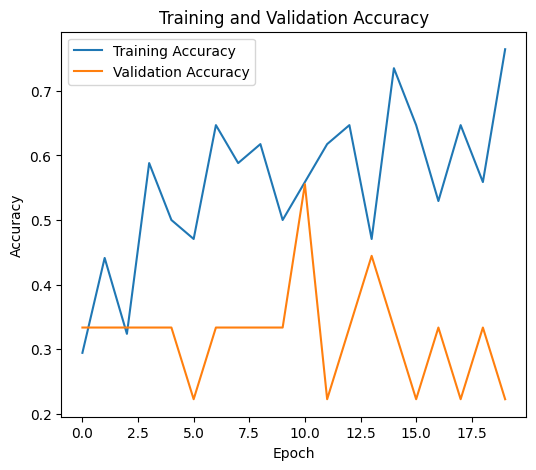

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

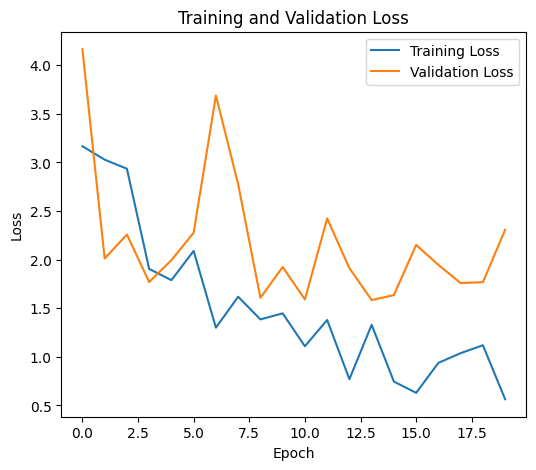

In [ ]:
plt.figure(figsize=(6,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=classes,
    zero_division=0
))

              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00         3
    moderate       0.25      0.67      0.36         3
       Dirty       0.00      0.00      0.00         3

    accuracy                           0.22         9
   macro avg       0.08      0.22      0.12         9
weighted avg       0.08      0.22      0.12         9

